### Pacotes importados

In [5]:
using LinearAlgebra
using Printf
using Plots

println("Pacotes carregados com sucesso.")

Pacotes carregados com sucesso.


## Chapter 13: Quasi-Newton methods

### Algorithm 13.1: Quasi-Newton BFGS method

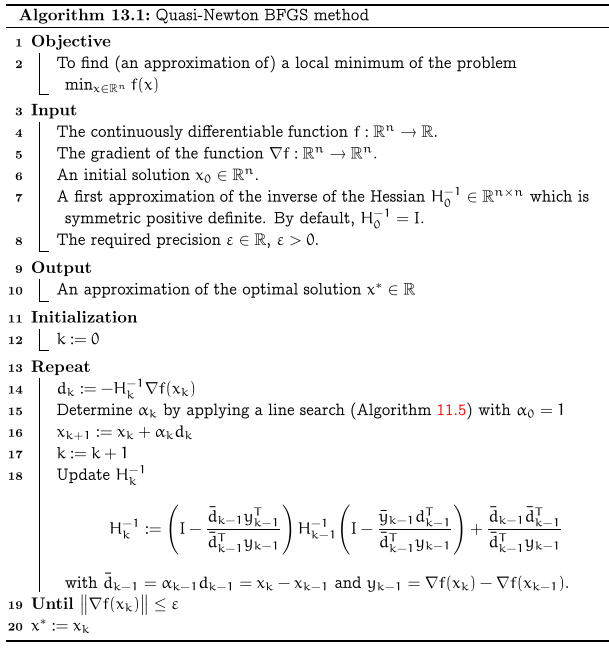

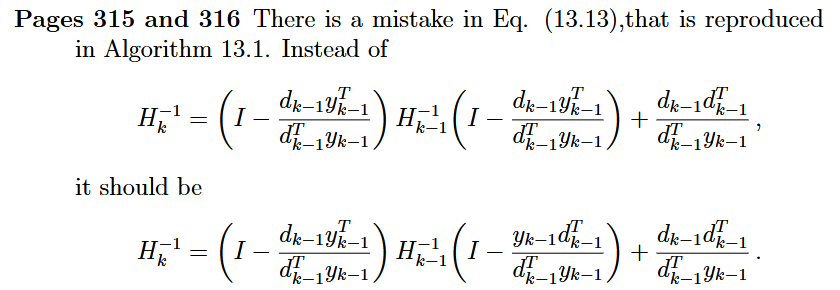

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$

In [6]:
function backtracking_armijo(f, g, x, p; α0=1.0, ρ=0.5, c=1e-4, max_backtracking=100)
    α = α0
    fx = f(x)
    gx = g(x)

    for j in 1:max_backtracking
        if f(x + α*p) <= fx + c*α*dot(gx, p)
            return α
        end
        α *= ρ
    end

    return α
end




function bfgs(f, g, x0; tol=1e-6, max_iter=200, α0=1.0, imprimir=true)
    n = length(x0)
    x = copy(x0)
    H = Matrix{Float64}(I, n, n)

    xs = [copy(x)]
    fs = [f(x)]
    grad_norms = [norm(g(x))]
    alphas = Float64[]

    if imprimir
        println("Iteração | α              | f(x)             | ||∇f(x)||")
        println("---------------------------------------------------------------")
    end

    for k in 0:max_iter
        grad = g(x)

        if imprimir
            α_print = k == 0 ? 0.0 : alphas[end]
            @printf("%8d | %14.6e | %16.8e | %12.6e\n",
                    k, α_print, f(x), norm(grad))
        end

        if norm(grad) < tol
            if imprimir
                println("\nCritério de parada atingido: ||∇f(x)|| < tolerância.")
            end
            break
        end

        if k == max_iter
            if imprimir
                println("\nNúmero máximo de iterações atingido.")
            end
            break
        end

        
        p = -H * grad

        
        α = backtracking_armijo(f, g, x, p; α0=α0)

        
        x_new = x + α*p
        s = x_new - x
        y = g(x_new) - grad

       
        if dot(y, s) > 1e-12
            ρ_bfgs = 1.0 / dot(y, s)
            Iₙ = Matrix{Float64}(I, n, n)
            H = (Iₙ - ρ_bfgs*s*y') * H * (Iₙ - ρ_bfgs*y*s') + ρ_bfgs*(s*s')
        else
            if imprimir
                println("Aviso: atualização BFGS ignorada porque yᵀs não foi positivo.")
            end
        end

        x = x_new

        push!(alphas, α)
        push!(xs, copy(x))
        push!(fs, f(x))
        push!(grad_norms, norm(g(x)))
    end

    return x, f(x), xs, fs, grad_norms, alphas
end




function plotar_resultados(f, xs, fs, grad_norms; titulo="BFGS", xlim=(-3,3), ylim=(-3,3))
    caminho = reduce(hcat, xs)'

    p1 = plot(0:length(fs)-1, fs,
        marker=:circle,
        xlabel="Iteração",
        ylabel="f(x)",
        title="Convergência de f(x) - $titulo",
        label="f(x)")

    p2 = plot(0:length(grad_norms)-1, grad_norms,
        marker=:square,
        xlabel="Iteração",
        ylabel="||∇f(x)||",
        yscale=:log10,
        title="Norma do gradiente - $titulo",
        label="||∇f(x)||")

    x1_range = range(xlim[1], xlim[2], length=120)
    x2_range = range(ylim[1], ylim[2], length=120)

    p3 = contour(x1_range, x2_range,
        (a,b) -> f([a,b]),
        xlabel="x₁",
        ylabel="x₂",
        title="Curvas de nível e trajetória - $titulo",
        label="f(x)")

    plot!(p3, caminho[:,1], caminho[:,2],
        marker=:circle,
        linewidth=2,
        label="trajetória BFGS")

    scatter!(p3, [caminho[1,1]], [caminho[1,2]],
        marker=:star5,
        markersize=8,
        label="início")

    scatter!(p3, [caminho[end,1]], [caminho[end,2]],
        marker=:diamond,
        markersize=8,
        label="fim")

    display(p1)
    display(p2)
    display(p3)
end

plotar_resultados (generic function with 1 method)

#### the Rosenbrock problem

EXEMPLO 5.8
f(x₁,x₂) = 1/2*x₁² + x₁*cos(x₂)
Ponto inicial x0 = [1.0, 1.0]
Iteração | α              | f(x)             | ||∇f(x)||
---------------------------------------------------------------
       0 |   0.000000e+00 |   1.04030231e+00 | 1.755165e+00
       1 |   1.000000e+00 |   2.90430181e-01 | 9.609418e-01
       2 |   1.000000e+00 |  -1.05885587e-03 | 5.024503e-02
Aviso: atualização BFGS ignorada porque yᵀs não foi positivo.
       3 |   1.000000e+00 |  -3.41910530e-03 | 6.485736e-02
Aviso: atualização BFGS ignorada porque yᵀs não foi positivo.
       4 |   1.000000e+00 |  -8.91142587e-03 | 1.042409e-01
Aviso: atualização BFGS ignorada porque yᵀs não foi positivo.
       5 |   1.000000e+00 |  -2.29988115e-02 | 1.654088e-01
Aviso: atualização BFGS ignorada porque yᵀs não foi positivo.
       6 |   1.000000e+00 |  -5.78726328e-02 | 2.540667e-01
Aviso: atualização BFGS ignorada porque yᵀs não foi positivo.
       7 |   1.000000e+00 |  -1.36713345e-01 | 3.591496e-01
Aviso: atualiza

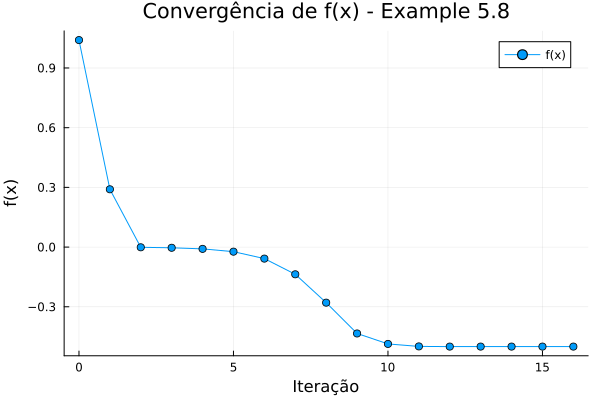

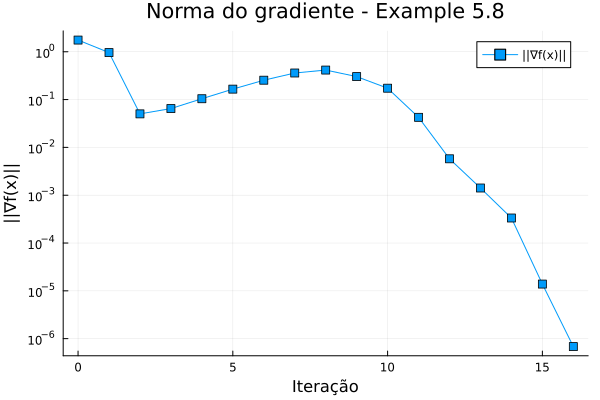

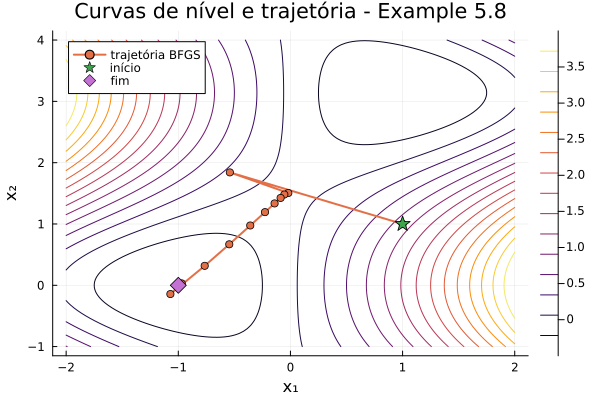

In [7]:
f_ex58(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

g_ex58(x) = [
    x[1] + cos(x[2]);
    -x[1]*sin(x[2])
]

x0_ex58 = [1.0, 1.0]

println("============================================================")
println("EXEMPLO 5.8")
println("f(x₁,x₂) = 1/2*x₁² + x₁*cos(x₂)")
println("Ponto inicial x0 = ", x0_ex58)
println("============================================================")

xopt_ex58, fopt_ex58, xs_ex58, fs_ex58, grad_ex58, alphas_ex58 =
    bfgs(f_ex58, g_ex58, x0_ex58; tol=1e-6, max_iter=200, imprimir=true)

println("\n================ RESULTADO FINAL - EXEMPLO 5.8 ================")
println("x* = ", xopt_ex58)
println("f(x*) = ", fopt_ex58)
println("||∇f(x*)|| = ", norm(g_ex58(xopt_ex58)))
println("número de iterações = ", length(fs_ex58)-1)
println("================================================================")

plotar_resultados(f_ex58, xs_ex58, fs_ex58, grad_ex58;
    titulo="Example 5.8",
    xlim=(-2,2),
    ylim=(-1,4))

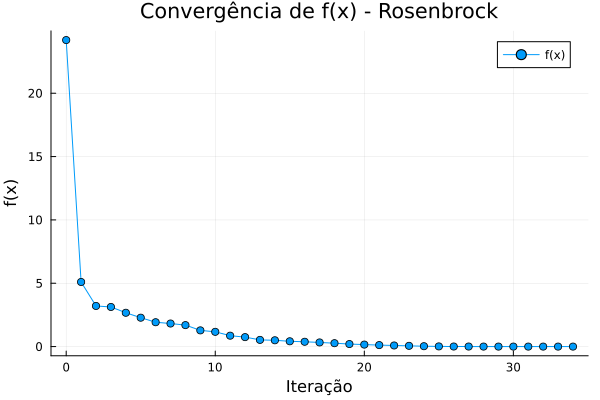

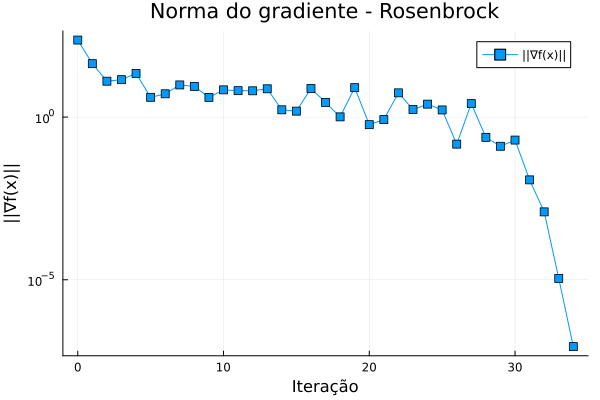

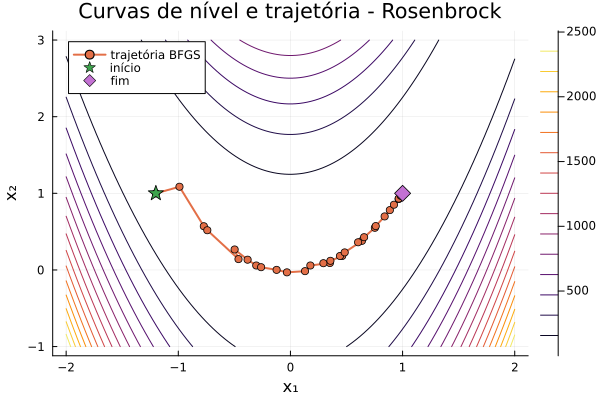

PROBLEMA DE ROSENBROCK
f(x₁,x₂) = 100(x₂ - x₁²)² + (1 - x₁)²
Ponto inicial x0 = [-1.2, 1.0]
Iteração | α              | f(x)             | ||∇f(x)||
---------------------------------------------------------------
       0 |   0.000000e+00 |   2.42000000e+01 | 2.328677e+02
       1 |   9.765625e-04 |   5.10111266e+00 | 4.389852e+01
       2 |   1.250000e-01 |   3.20842357e+00 | 1.266425e+01
       3 |   1.000000e+00 |   3.12866102e+00 | 1.413741e+01
       4 |   1.000000e+00 |   2.67087014e+00 | 2.194176e+01
       5 |   1.000000e+00 |   2.28156829e+00 | 4.046202e+00
       6 |   1.000000e+00 |   1.92422723e+00 | 5.184538e+00
       7 |   2.500000e-01 |   1.82194897e+00 | 9.716320e+00
       8 |   1.000000e+00 |   1.69629477e+00 | 8.757659e+00
       9 |   1.000000e+00 |   1.28113325e+00 | 4.034390e+00
      10 |   5.000000e-01 |   1.16629884e+00 | 6.875349e+00
      11 |   1.000000e+00 |   8.61868886e-01 | 6.482765e+00
      12 |   1.000000e+00 |   7.48283604e-01 | 6.436150e+00
      1

In [8]:
f_rosen(x) = 100.0*(x[2] - x[1]^2)^2 + (1.0 - x[1])^2

g_rosen(x) = [
    -400.0*x[1]*(x[2] - x[1]^2) - 2.0*(1.0 - x[1]);
     200.0*(x[2] - x[1]^2)
]

x0_rosen = [-1.2, 1.0]

println("============================================================")
println("PROBLEMA DE ROSENBROCK")
println("f(x₁,x₂) = 100(x₂ - x₁²)² + (1 - x₁)²")
println("Ponto inicial x0 = ", x0_rosen)
println("============================================================")

xopt_rosen, fopt_rosen, xs_rosen, fs_rosen, grad_rosen, alphas_rosen =
    bfgs(f_rosen, g_rosen, x0_rosen; tol=1e-6, max_iter=500, imprimir=true)

println("\n================ RESULTADO FINAL - ROSENBROCK ================")
println("x* = ", xopt_rosen)
println("f(x*) = ", fopt_rosen)
println("||∇f(x*)|| = ", norm(g_rosen(xopt_rosen)))
println("número de iterações = ", length(fs_rosen)-1)
println("==============================================================")

plotar_resultados(f_rosen, xs_rosen, fs_rosen, grad_rosen;
    titulo="Rosenbrock",
    xlim=(-2,2),
    ylim=(-1,3))